# 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 2. Load Dataset

In [4]:
df = pd.read_csv("crowd_dataset_IR_camera_final.csv")
print(df.head())

             Timestamp  IR_Count  Camera_Count  Total_Count  Density  \
0  2025-01-01 00:02:12         4             3            3     0.06   
1  2025-01-01 00:07:12         2             1            2     0.04   
2  2025-01-01 00:09:28         1             0            1     0.02   
3  2025-01-01 00:11:09         1             0            1     0.02   
4  2025-01-01 00:14:47         0             2            1     0.02   

   Next_Count  
0         2.0  
1         1.0  
2         1.0  
3         1.0  
4         1.0  


# 3. Dataset Info

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Timestamp     14999 non-null  str    
 1   IR_Count      14999 non-null  int64  
 2   Camera_Count  14999 non-null  int64  
 3   Total_Count   14999 non-null  int64  
 4   Density       14999 non-null  float64
 5   Next_Count    14999 non-null  float64
dtypes: float64(2), int64(3), str(1)
memory usage: 703.2 KB
None
           IR_Count  Camera_Count   Total_Count       Density    Next_Count
count  14999.000000  14999.000000  14999.000000  14999.000000  14999.000000
mean       2.020735      6.870925      6.870525      0.137410      6.870658
std        1.410355      5.334498      4.440135      0.088803      4.440049
min        0.000000      0.000000      1.000000      0.020000      1.000000
25%        1.000000      3.000000      3.000000      0.060000      3.000000
50%        2.000000      6.000000     

# 4. Create Target Variable

In [6]:
df['Next_Count'] = df['Total_Count'].shift(-1)
df = df.dropna()

# 5. Feature Engineering

In [11]:
# Previous Count Features
df['Prev_Total_Count'] = df['Total_Count'].shift(1)
df['Prev_IR_Count'] = df['IR_Count'].shift(1)
df['Prev_Camera_Count'] = df['Camera_Count'].shift(1)

# Rolling Average Features
df['Rolling_Avg_3'] = df['Total_Count'].rolling(3).mean()
df['Rolling_Avg_5'] = df['Total_Count'].rolling(5).mean()

# Change Features
df['Count_Change'] = df['Total_Count'].diff()
df['Density_Change'] = df['Density'].diff()

# Ratio Feature
df['Camera_IR_Ratio'] = df['Camera_Count'] / (df['IR_Count'] + 1)

# Interaction Feature
df['IR_Camera_Product'] = df['IR_Count'] * df['Camera_Count']

# ----------------------------
# Timestamp Feature Engineering
# ----------------------------

# Replace 'Timestamp' with your actual column name if different
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Hour'] = df['Timestamp'].dt.hour
df['Minute'] = df['Timestamp'].dt.minute
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

# Drop original timestamp column
df.drop('Timestamp', axis=1, inplace=True)

# Time index feature
df['Time_Index'] = np.arange(len(df))

# Remove null values created due to shift/rolling
df = df.dropna()

print("Feature Engineering Completed Successfully")
print(df.head())

Feature Engineering Completed Successfully
    IR_Count  Camera_Count  Total_Count  Density  Next_Count  \
8          3             7            4     0.08         4.0   
9          2             3            4     0.08         3.0   
10         3             0            3     0.06         2.0   
11         4             1            2     0.04         1.0   
12         4             0            1     0.02         3.0   

    Prev_Total_Count  Prev_IR_Count  Prev_Camera_Count  Rolling_Avg_3  \
8                3.0            4.0                7.0       2.666667   
9                4.0            3.0                7.0       3.666667   
10               4.0            2.0                3.0       3.666667   
11               3.0            3.0                0.0       3.000000   
12               2.0            4.0                1.0       2.000000   

    Rolling_Avg_5  Count_Change  Density_Change  Camera_IR_Ratio  \
8             2.0           1.0            0.02             1.75 

# 6. Define X & y

In [12]:
X = df.drop('Next_Count', axis=1)
y = df['Next_Count']

# 7. Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# 8. Feature Scaling

In [14]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Baseline Training (All Models)

In [16]:
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

lr.fit(X_train,y_train)
rf.fit(X_train,y_train)
xgb.fit(X_train,y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

# LSTM training

In [17]:
# Baseline LSTM
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1],1)
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1],1)

baseline_lstm = Sequential([
    LSTM(50,activation='relu',input_shape=(X_train_lstm.shape[1],1)),
    Dense(1)
])

baseline_lstm.compile(optimizer='adam',loss='mse')
baseline_lstm.fit(X_train_lstm,y_train,epochs=80,batch_size=16,verbose=0)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# 10. Baseline Predictions

In [18]:
lr_pred_before = lr.predict(X_test)
rf_pred_before = rf.predict(X_test)
xgb_pred_before = xgb.predict(X_test)
lstm_pred_before = baseline_lstm.predict(X_test_lstm)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


# 11. Accuracy Before Tuning

In [19]:
def evaluate(name,y_true,pred):
    print(name)
    print("R2:",r2_score(y_true,pred))
    print("RMSE:",np.sqrt(mean_squared_error(y_true,pred)))
    print("MAE:",mean_absolute_error(y_true,pred))
    print("-------------------")

evaluate("Linear Before",y_test,lr_pred_before)
evaluate("RF Before",y_test,rf_pred_before)
evaluate("XGB Before",y_test,xgb_pred_before)
evaluate("LSTM Before",y_test,lstm_pred_before)

Linear Before
R2: 0.9420686368453692
RMSE: 1.0831129526956542
MAE: 0.8716626632693092
-------------------
RF Before
R2: 0.9474660912053776
RMSE: 1.0314228143756936
MAE: 0.8464242828552369
-------------------
XGB Before
R2: 0.945321834005635
RMSE: 1.0522618982539216
MAE: 0.8592240676790814
-------------------
LSTM Before
R2: 0.9456600119653198
RMSE: 1.0490027937401196
MAE: 0.8593994924591095
-------------------


# Overfitting Check Before Tuning

In [22]:
from sklearn.metrics import r2_score

# Random Forest
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("Random Forest Before Tuning")
print("Train R2:", r2_score(y_train, rf_train_pred))
print("Test R2:", r2_score(y_test, rf_test_pred))


# XGBoost
xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

print("\nXGBoost Before Tuning")
print("Train R2:", r2_score(y_train, xgb_train_pred))
print("Test R2:", r2_score(y_test, xgb_test_pred))


# Linear Regression
lr_train_pred = lr.predict(X_train)
lr_test_pred = lr.predict(X_test)

print("\nLinear Regression Before Tuning")
print("Train R2:", r2_score(y_train, lr_train_pred))
print("Test R2:", r2_score(y_test, lr_test_pred))

Random Forest Before Tuning
Train R2: 0.9923399353045146
Test R2: 0.9474660912053776

XGBoost Before Tuning
Train R2: 0.977301287256116
Test R2: 0.945321834005635

Linear Regression Before Tuning
Train R2: 0.9400151241720245
Test R2: 0.9420686368453692


# 12. Hyperparameter Tuning – Random Forest

In [20]:
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

# 13. Grid Search – Random Forest

In [21]:
rf_grid = GridSearchCV(
    RandomForestRegressor(),
    rf_params,
    cv=5
)

rf_grid.fit(X_train,y_train)
best_rf = rf_grid.best_estimator_

# 14. Hyperparameter Tuning – XGBoost

In [23]:
xgb_params = {
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.01,0.1]
}

# 15. Grid Search – XGBoost

In [24]:
xgb_grid = GridSearchCV(
    XGBRegressor(),
    xgb_params,
    cv=5
)

xgb_grid.fit(X_train,y_train)
best_xgb = xgb_grid.best_estimator_

# 16. Hyperparameter Tuning – Linear Regression

In [25]:
ridge_params = {
    'alpha':[0.1,1,10]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5
)

ridge_grid.fit(X_train,y_train)
best_lr = ridge_grid.best_estimator_

# 17. Hyperparameter Tuning – LSTM

In [26]:
tuned_lstm = Sequential([
    LSTM(100,activation='relu',input_shape=(X_train_lstm.shape[1],1)),
    Dense(1)
])

tuned_lstm.compile(optimizer='adam',loss='mse')
tuned_lstm.fit(X_train_lstm,y_train,epochs=80,batch_size=8,verbose=0)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# 18. Train Tuned Models

In [27]:
best_rf.fit(X_train,y_train)
best_xgb.fit(X_train,y_train)
best_lr.fit(X_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


# 19. Predictions After Tuning

In [28]:
lr_pred_after = best_lr.predict(X_test)
rf_pred_after = best_rf.predict(X_test)
xgb_pred_after = best_xgb.predict(X_test)
lstm_pred_after = tuned_lstm.predict(X_test_lstm)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


# 20. Evaluation of All Models After Tuning

In [29]:
evaluate("Linear After",y_test,lr_pred_after)
evaluate("RF After",y_test,rf_pred_after)
evaluate("XGB After",y_test,xgb_pred_after)
evaluate("LSTM After",y_test,lstm_pred_after)

Linear After
R2: 0.9420737539305628
RMSE: 1.083065115881995
MAE: 0.8716017905729716
-------------------
RF After
R2: 0.9493085208654041
RMSE: 1.013174748976876
MAE: 0.8364537435499488
-------------------
XGB After
R2: 0.9498254481139226
RMSE: 1.0079955778247536
MAE: 0.8339344001436647
-------------------
LSTM After
R2: 0.9473602610960747
RMSE: 1.032461197709619
MAE: 0.8475167798232524
-------------------


# Overfitting Check After Tuning

In [30]:
# Random Forest After Tuning
rf_train_pred_after = best_rf.predict(X_train)
rf_test_pred_after = best_rf.predict(X_test)

print("Random Forest After Tuning")
print("Train R2:", r2_score(y_train, rf_train_pred_after))
print("Test R2:", r2_score(y_test, rf_test_pred_after))


# XGBoost After Tuning
xgb_train_pred_after = best_xgb.predict(X_train)
xgb_test_pred_after = best_xgb.predict(X_test)

print("\nXGBoost After Tuning")
print("Train R2:", r2_score(y_train, xgb_train_pred_after))
print("Test R2:", r2_score(y_test, xgb_test_pred_after))


# Linear After Tuning
lr_train_pred_after = best_lr.predict(X_train)
lr_test_pred_after = best_lr.predict(X_test)

print("\nLinear After Tuning")
print("Train R2:", r2_score(y_train, lr_train_pred_after))
print("Test R2:", r2_score(y_test, lr_test_pred_after))

Random Forest After Tuning
Train R2: 0.9492944593235416
Test R2: 0.9493085208654041

XGBoost After Tuning
Train R2: 0.9512990989407332
Test R2: 0.9498254481139226

Linear After Tuning
Train R2: 0.9400149955954665
Test R2: 0.9420737539305628


# 21. Before vs After Accuracy Comparison Graph

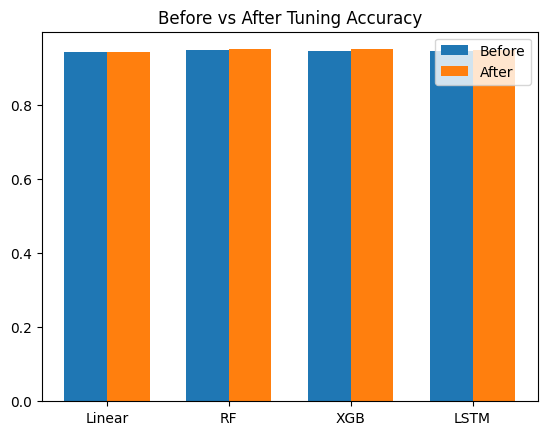

In [31]:
models = ['Linear','RF','XGB','LSTM']

before_scores = [
    r2_score(y_test,lr_pred_before),
    r2_score(y_test,rf_pred_before),
    r2_score(y_test,xgb_pred_before),
    r2_score(y_test,lstm_pred_before)
]

after_scores = [
    r2_score(y_test,lr_pred_after),
    r2_score(y_test,rf_pred_after),
    r2_score(y_test,xgb_pred_after),
    r2_score(y_test,lstm_pred_after)
]

x=np.arange(len(models))
width=0.35

plt.bar(x-width/2,before_scores,width,label='Before')
plt.bar(x+width/2,after_scores,width,label='After')

plt.xticks(x,models)
plt.legend()
plt.title("Before vs After Tuning Accuracy")
plt.show()

# 22. Feature Importance

In [32]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_rf.feature_importances_
})

print(importance.sort_values(by='Importance',ascending=False))

              Feature  Importance
2         Total_Count    0.520025
3             Density    0.474052
1        Camera_Count    0.004414
15             Minute    0.000510
13         Time_Index    0.000204
6   Prev_Camera_Count    0.000166
8       Rolling_Avg_5    0.000156
14               Hour    0.000132
11    Camera_IR_Ratio    0.000094
7       Rolling_Avg_3    0.000084
12  IR_Camera_Product    0.000038
18          DayOfWeek    0.000038
4    Prev_Total_Count    0.000031
16                Day    0.000022
5       Prev_IR_Count    0.000015
0            IR_Count    0.000012
9        Count_Change    0.000004
10     Density_Change    0.000002
17              Month    0.000000


# 23. Before vs After Accuracy Comparison Graph

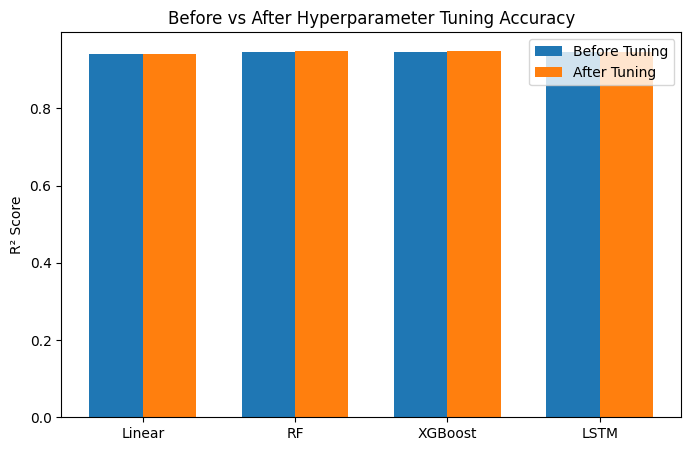

In [34]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Linear', 'RF', 'XGBoost', 'LSTM']

before_scores = [
    r2_score(y_test, lr_pred_before),
    r2_score(y_test, rf_pred_before),
    r2_score(y_test, xgb_pred_before),
    r2_score(y_test, lstm_pred_before)
]

after_scores = [
    r2_score(y_test, lr_pred_after),
    r2_score(y_test, rf_pred_after),
    r2_score(y_test, xgb_pred_after),
    r2_score(y_test, lstm_pred_after)
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x-width/2, before_scores, width, label='Before Tuning')
plt.bar(x+width/2, after_scores, width, label='After Tuning')

plt.xticks(x, models)
plt.ylabel("R² Score")
plt.title("Before vs After Hyperparameter Tuning Accuracy")
plt.legend()
plt.show()

# Final Model Accuracy Comparison Graph

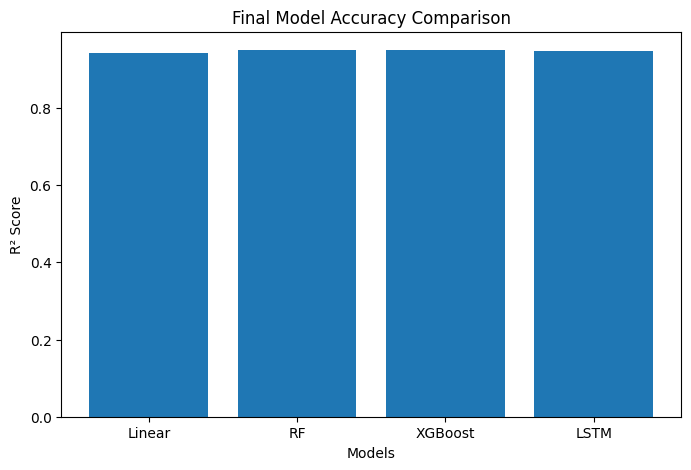

In [35]:
final_scores = [
    r2_score(y_test, lr_pred_after),
    r2_score(y_test, rf_pred_after),
    r2_score(y_test, xgb_pred_after),
    r2_score(y_test, lstm_pred_after)
]

plt.figure(figsize=(8,5))
plt.bar(models, final_scores)

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Final Model Accuracy Comparison")
plt.show()

# Feature Importance Graph (Random Forest)

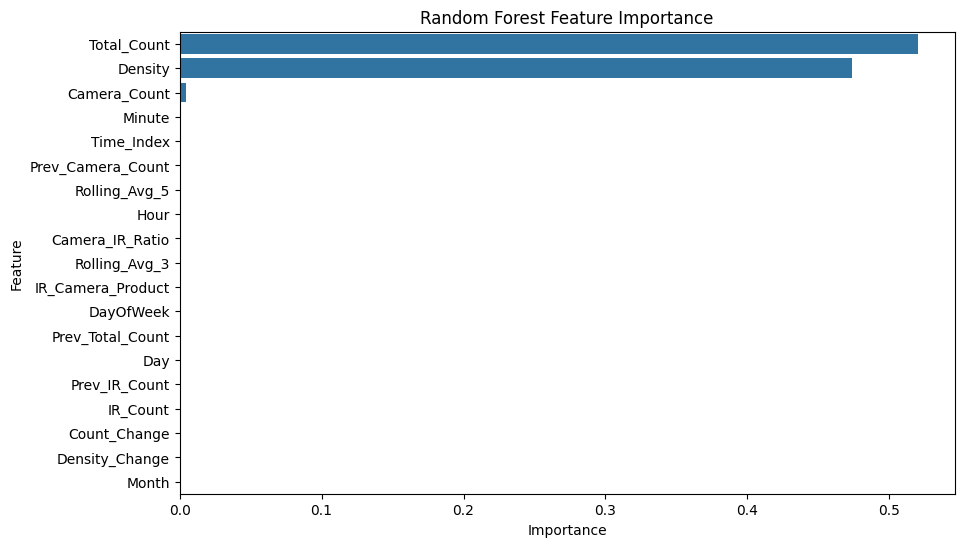

In [36]:
import seaborn as sns

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=importance['Importance'],
    y=importance['Feature']
)

plt.title("Random Forest Feature Importance")
plt.show()

# Feature Importance Graph (XGBoost)

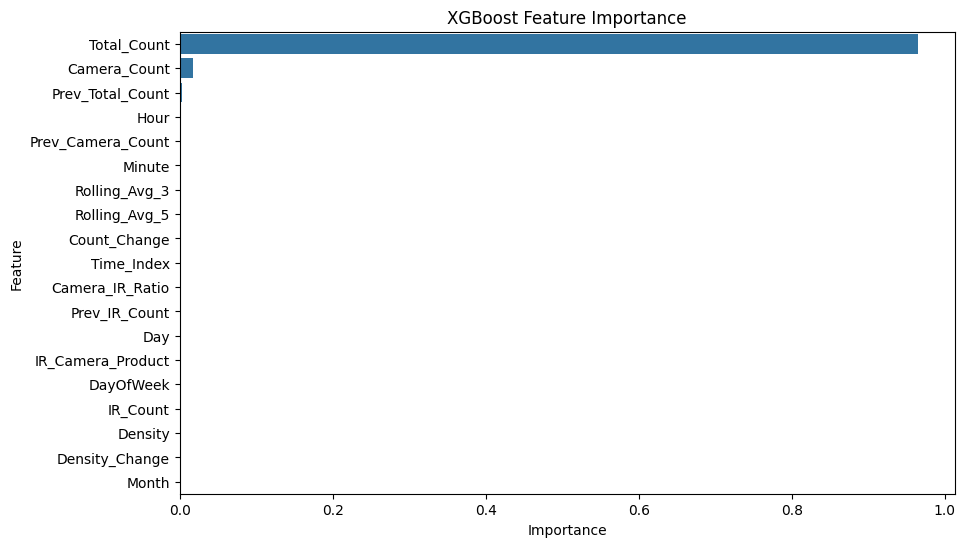

In [37]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=xgb_importance['Importance'],
    y=xgb_importance['Feature']
)

plt.title("XGBoost Feature Importance")
plt.show()

# Linear Regression Actual vs Predicted

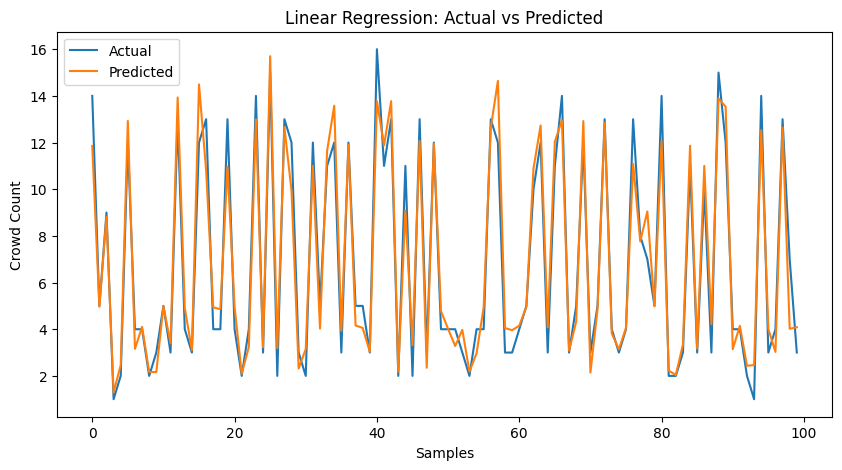

In [38]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(lr_pred_after[:100], label="Predicted")

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Crowd Count")
plt.legend()
plt.show()

# Random Forest Actual vs Predicted

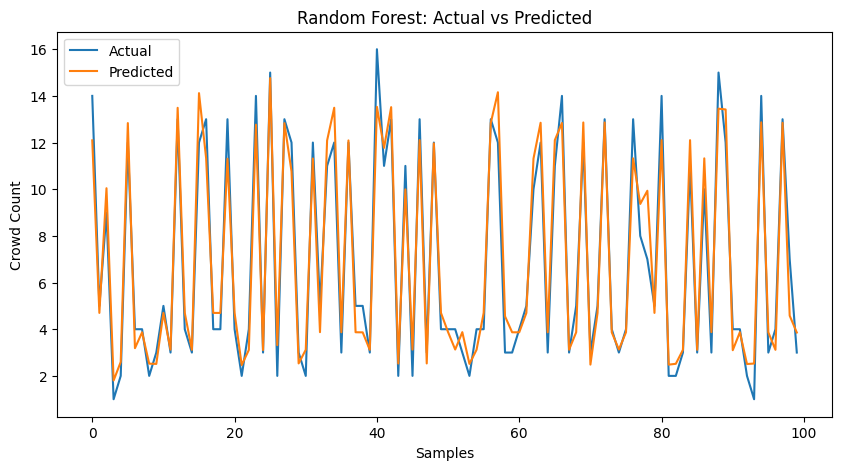

In [39]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(rf_pred_after[:100], label="Predicted")

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Crowd Count")
plt.legend()
plt.show()

# XGBoost Actual vs Predicted

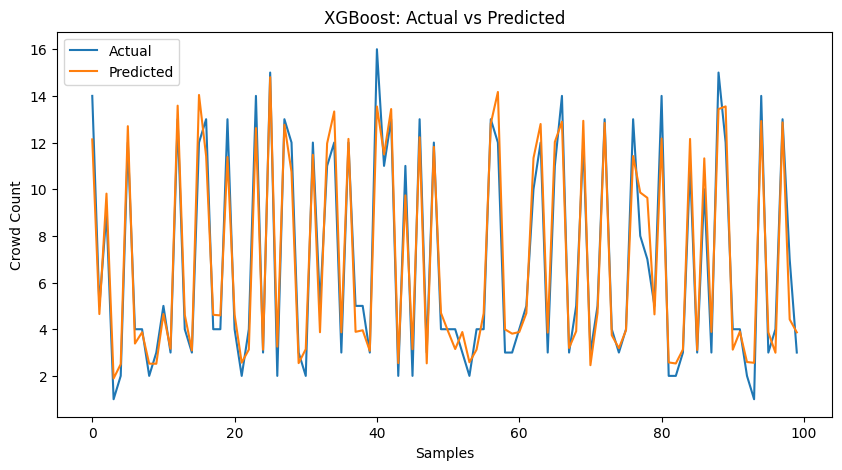

In [40]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(xgb_pred_after[:100], label="Predicted")

plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Crowd Count")
plt.legend()
plt.show()

# LSTM Actual vs Predicted

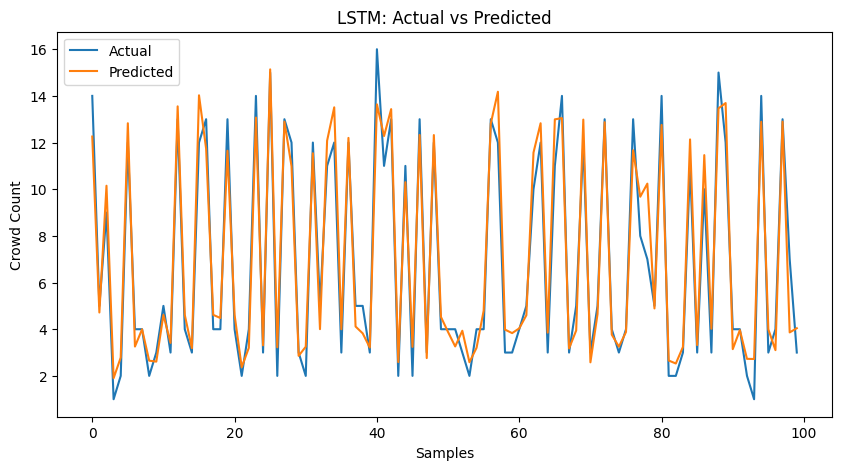

In [41]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(lstm_pred_after[:100], label="Predicted")

plt.title("LSTM: Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Crowd Count")
plt.legend()
plt.show()

# Correlation Heatmap

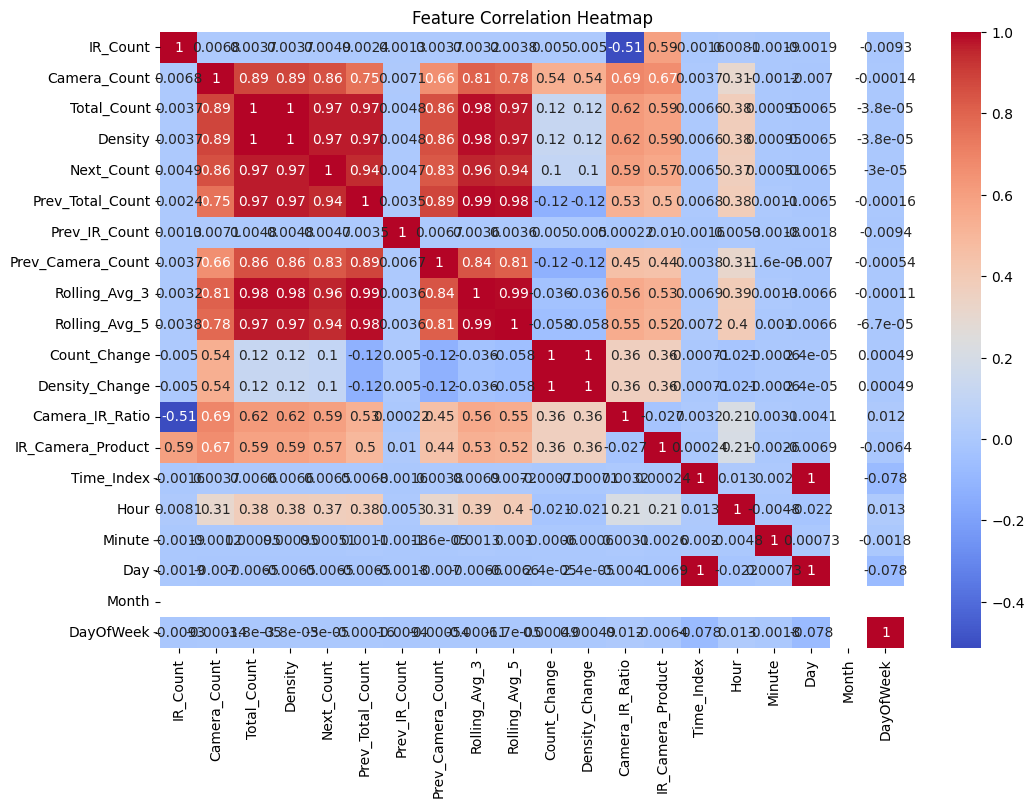

In [42]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

# Distribution of Total Crowd Count

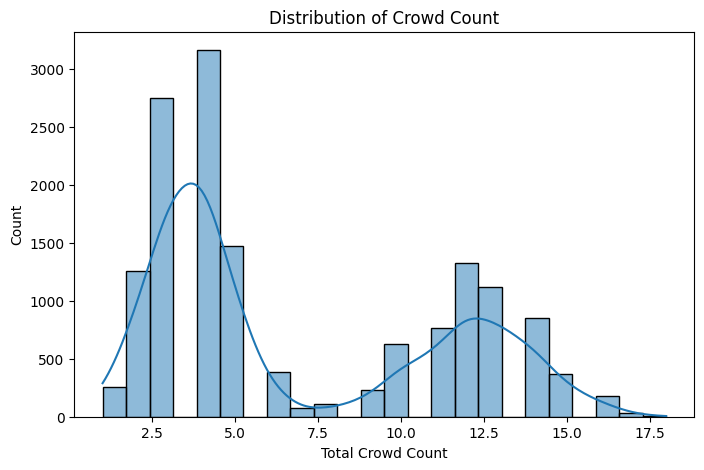

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Total_Count'],
    kde=True
)

plt.title("Distribution of Crowd Count")
plt.xlabel("Total Crowd Count")
plt.show()

# LSTM Training Loss Graph

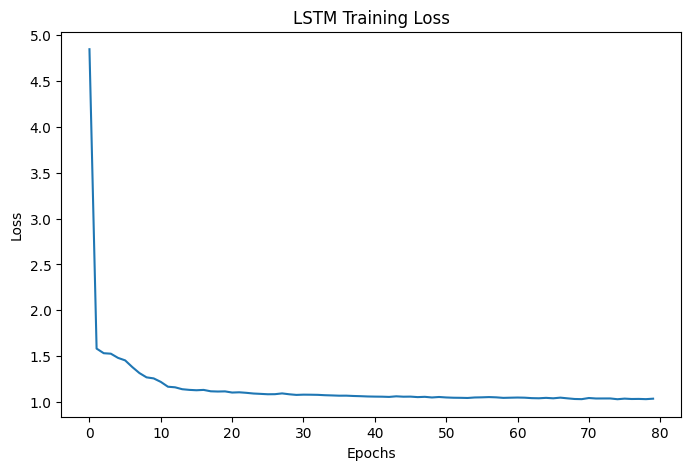

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    tuned_lstm.history.history['loss']
)

plt.title("LSTM Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Scatter Plot: Actual vs Predicted

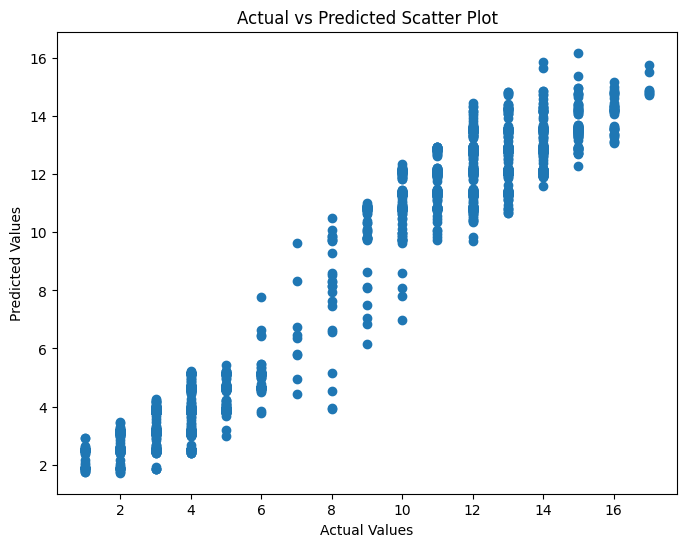

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    xgb_pred_after
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Scatter Plot")
plt.show()

# Residual Plot for XGBoost

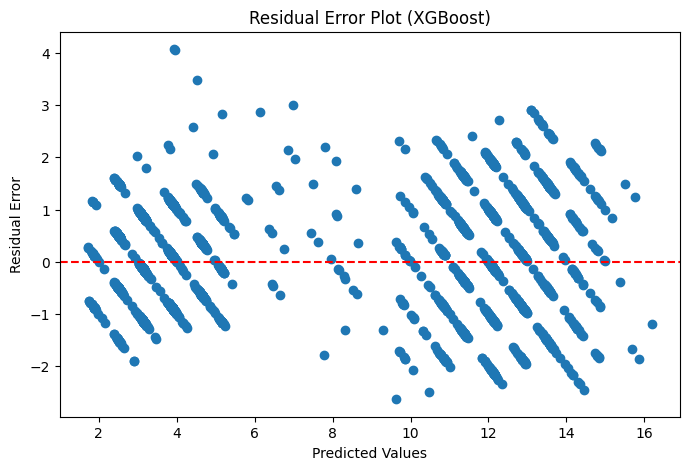

In [46]:
residuals = y_test - xgb_pred_after

plt.figure(figsize=(8,5))

plt.scatter(
    xgb_pred_after,
    residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residual Error")
plt.title("Residual Error Plot (XGBoost)")
plt.show()

# Histogram of Residual Errors

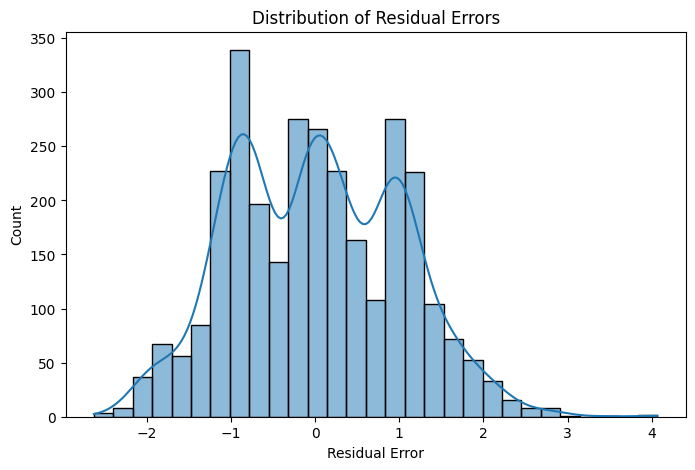

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Distribution of Residual Errors")
plt.xlabel("Residual Error")
plt.show()

# Residual Plot for All Models

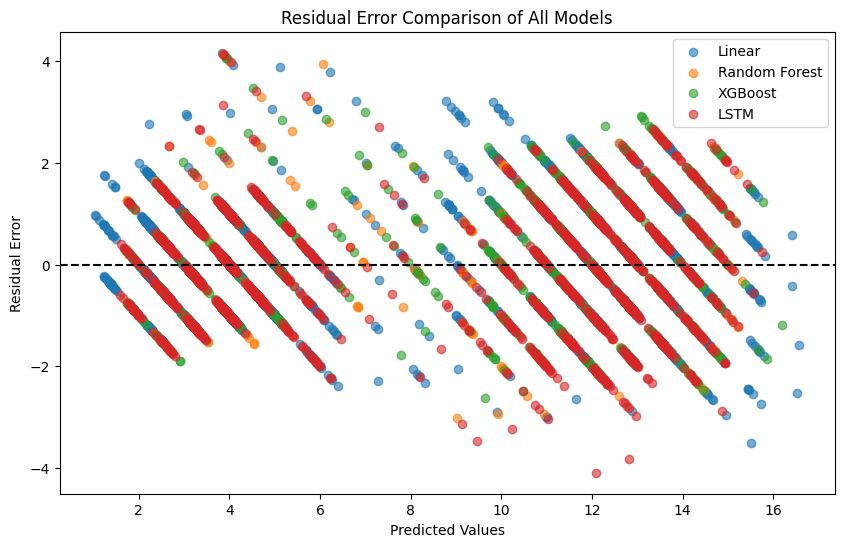

In [48]:
models = {
    "Linear": lr_pred_after,
    "Random Forest": rf_pred_after,
    "XGBoost": xgb_pred_after,
    "LSTM": lstm_pred_after.flatten()
}

plt.figure(figsize=(10,6))

for name, pred in models.items():
    residual = y_test - pred
    plt.scatter(pred, residual, label=name, alpha=0.6)

plt.axhline(y=0, color='black', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residual Error")
plt.title("Residual Error Comparison of All Models")
plt.legend()
plt.show()

# 24. Model Saving

In [49]:
joblib.dump(best_lr,'best_linear.pkl')
joblib.dump(best_rf,'best_rf.pkl')
joblib.dump(best_xgb,'best_xgb.pkl')
tuned_lstm.save('best_lstm.h5')

print("All models saved successfully")

All models saved successfully


In [51]:
import joblib
import pandas as pd

# Load saved model
model = joblib.load("Pickel file\\best_xgb.pkl")

print("Model loaded successfully!")
print(model)
# Sample input (replace values if needed)
sample_data = pd.DataFrame({
    'IR_Count': [3],
    'Camera_Count': [7],
    'Total_Count': [4],
    'Density': [0.08],
    'Prev_Total_Count': [3],
    'Prev_IR_Count': [4],
    'Prev_Camera_Count': [7],
    'Rolling_Avg_3': [2.66],
    'Rolling_Avg_5': [2.0],
    'Count_Change': [1],
    'Density_Change': [0.02],
    'Camera_IR_Ratio': [1.75],
    'IR_Camera_Product': [21],
    'Time_Index': [4],
    'Hour': [0],
    'Minute': [24],
    'Day': [1],
    'Month': [1],
    'DayOfWeek': [2]
})

prediction = model.predict(sample_data)

print("Predicted Next Crowd Count:", prediction[0])
print(df.iloc[8])


Model loaded successfully!
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)
Predicted Next Crowd Count: 3.8586223
IR_Count              0.000000
Camera_Count          7.000000
Total_Count           5.000000
Density               0.100000
Next_Count            5.000000
Prev_Total_Count      4.000000
Prev

In [53]:
import joblib
import pandas as pd

model = joblib.load("Pickel file\\best_xgb.pkl")

sample = pd.DataFrame({
    'IR_Count':[13],
    'Camera_Count':[2],
    'Total_Count':[9],
    'Density':[0.18],
    'Distance':[7],
    'Prev_Total_Count':[8],
    'Prev_Camera_Count':[2],
    'Prev_IR_Count':[12],
    'Rolling_Avg_3':[8.5],
    'Rolling_Avg_5':[7.8],
    'Count_Change':[1],
    'Camera_IR_Ratio':[0.14],
    'IR_Camera_Product':[26],
    'Time_Index':[50]
})

print(model.predict(sample))

ValueError: feature_names mismatch: ['IR_Count', 'Camera_Count', 'Total_Count', 'Density', 'Prev_Total_Count', 'Prev_IR_Count', 'Prev_Camera_Count', 'Rolling_Avg_3', 'Rolling_Avg_5', 'Count_Change', 'Density_Change', 'Camera_IR_Ratio', 'IR_Camera_Product', 'Time_Index', 'Hour', 'Minute', 'Day', 'Month', 'DayOfWeek'] ['IR_Count', 'Camera_Count', 'Total_Count', 'Density', 'Distance', 'Prev_Total_Count', 'Prev_Camera_Count', 'Prev_IR_Count', 'Rolling_Avg_3', 'Rolling_Avg_5', 'Count_Change', 'Camera_IR_Ratio', 'IR_Camera_Product', 'Time_Index']
expected Day, DayOfWeek, Density_Change, Minute, Hour, Month in input data
training data did not have the following fields: Distance